# LGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

In [2]:
# File Paths for train and test data
BASE_PATH = r"../playground-series-s5e12/"
TRAIN_PATH = BASE_PATH + "train.csv"
TEST_PATH =  BASE_PATH + "test.csv"

In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

In [4]:
import datetime
import re
import pandas as pd
LOG_FILE = "logger.txt"
def summarize_experiment_logs(log_file=LOG_FILE, sort_by_roc=True, top_n=None):
    """
    Summarize experiments from a logger.txt file.
    
    Args:
        log_file (str): Path to the log file.
        sort_by_roc (bool): Whether to sort by ROC-AUC descending.
        top_n (int or None): If specified, return only the top N experiments.
    
    Returns:
        pd.DataFrame: DataFrame with Timestamp and ROC-AUC Score.
    """
    timestamps = []
    roc_scores = []

    with open(log_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        # Capture timestamp
        if line.startswith("Timestamp:"):
            ts = line.split("Timestamp:")[1].strip()
            timestamps.append(ts)
        # Capture ROC-AUC score
        elif line.startswith("ROC AUC Score:"):
            match = re.findall(r"[\d\.]+", line)
            if match:
                roc_scores.append(float(match[0]))

    # Make DataFrame
    df = pd.DataFrame({
        "Timestamp": timestamps,
        "ROC-AUC Score": roc_scores
    })

    if sort_by_roc:
        df = df.sort_values("ROC-AUC Score", ascending=False).reset_index(drop=True)

    if top_n is not None:
        df = df.head(top_n)

    return df


n_splits = 5

def format_confusion_matrix(cm, labels=None):
    """
    Returns a list of strings representing a nicely formatted confusion matrix.
    """
    if labels is None:
        labels = [str(i) for i in range(cm.shape[0])]
    
    text = []
    # Header
    header = " " * 10 + "".join([f"{lbl:>10}" for lbl in labels])
    text.append(header)
    text.append("-" * (10 + 10*len(labels)))
    
    # Rows
    for i, row in enumerate(cm):
        row_str = f"{labels[i]:<10}" + "".join([f"{int(round(v)):>10}" for v in row])
        text.append(row_str)
    
    return text


def log_experiment_pretty(
    model,
    roc_score,
    avg_report,
    features_used=None,
    conf_mat=None,
    notes=None,
):

    # ---- Params ----
    params = model.get_params()

    # ---- Feature importance ----
    try:
        importances = model.feature_importances_
    except:
        importances = None

    # ---- Build the text block ----
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    text = []
    text.append("=" * 25 + " EXPERIMENT LOG " + "=" * 25)
    text.append(f"Timestamp: {timestamp}\n")
    text.append(f"ROC AUC Score: {roc_score:.5f}\n", )

    # --- Model parameters ---
    text.append("Model Parameters:")
    for k, v in params.items():
        text.append(f"    {k}: {v}")
    text.append("")

    # --- Features used ---
    if features_used:
        text.append(f"Features Used ({len(features_used)}):")
        text.append("    " + ", ".join(features_used))
        text.append("")

    # --- Feature importance ---
    if features_used and importances is not None:
        text.append("Feature Importances:")
        for feat, imp in zip(features_used, importances):
            text.append(f"    {feat}: {float(imp)}")
        text.append("")

    # --- ROC-AUC ---
    text.append(f"ROC-AUC Score: {roc_score}\n")

    # --- Cross-validation report ---
    text.append(f"=== {n_splits}-Fold Cross-Validation Classification Report (Averaged) ===\n")

    # Header
    header = f"{'Class':<10}{'Precision':>10}{'Recall':>10}{'F1-Score':>10}{'Support':>10}"
    text.append(header)
    text.append("-"*50)

    for label, metrics in avg_report.items():
        # Skip non-dict entries like 'accuracy'
        if not isinstance(metrics, dict):
            continue
        
        precision = metrics.get('precision', 0.0)
        recall = metrics.get('recall', 0.0)
        f1 = metrics.get('f1-score', 0.0)
        support = int(metrics.get('support', 0))
        
        line = f"{str(label):<10}{precision:>10.2f}{recall:>10.2f}{f1:>10.2f}{support:>10}"
        text.append(line)

    # Add accuracy separately if exists
    if 'accuracy' in avg_report:
        acc = avg_report['accuracy']
        text.append("-"*50)
        text.append(f"{'Accuracy':<10}{acc:>10.4f}")

    text.append("")


    # Confusion Matric Usage:
    avg_cm_text = format_confusion_matrix(conf_mat)
    text.append("=== Average Confusion Matrix (over CV folds) ===")
    text.extend(avg_cm_text)
    text.append("")  # blank line after

    # --- Additional notes ---
    if notes:
        text.append("Notes:")
        text.append(f"    {notes}\n")

    text.append("-" * 55 + "\n")

    # ---- Append to file ----
    with open(LOG_FILE, "a") as f:
        f.write("\n".join(text))

    print("✔ Logged experiment in readable format to logger.txt")


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [17]:
for c in CAT_COLS:
    display(train[c].value_counts())

gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64

ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64

education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64

income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64

smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64

employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64

family_history_diabetes
0    595419
1    104581
Name: count, dtype: int64

hypertension_history
0    572607
1    127393
Name: count, dtype: int64

cardiovascular_history
0    678773
1     21227
Name: count, dtype: int64

In [ ]:
NUM_COLS = [
    'age', 
    'alcohol_consumption_per_week', 
    'physical_activity_minutes_per_week', 
    'diet_score', 
    'sleep_hours_per_day', 
    'screen_time_hours_per_day', 
    'bmi', 
    'waist_to_hip_ratio', 
    'systolic_bp', 
    'diastolic_bp', 
    'heart_rate', 
    'cholesterol_total', 
    'hdl_cholesterol', 
    'ldl_cholesterol', 
    'triglycerides', 
]

CAT_COLS = [
    'gender',
    'ethnicity', 
    'education_level', 
    'income_level', 
    'smoking_status', 
    'employment_status',
    'family_history_diabetes', # Binary 1/0
    'hypertension_history', # Binary 1/0
    'cardiovascular_history', # Binary 1/0
    # 'diagnosed_diabetes' # Binary 1/0
]

BIN_COLS = [
    'family_history_diabetes', # Binary 1/0
    'hypertension_history', # Binary 1/0
    'cardiovascular_history', # Binary 1/0
]

TARGET = 'diagnosed_diabetes'


In [36]:
target = "diagnosed_diabetes"

numeric_features = [
    'age', 'alcohol_consumption_per_week',
    'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day',
    'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
    'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
    'ldl_cholesterol', 'triglycerides', 'family_history_diabetes',
    'hypertension_history', 'cardiovascular_history'
]

categorical_features = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

# --- Feature engineering ---


def bmi_category(row):
    bmi = row['bmi']

    if bmi < 18.5:
        category = "underweight"
    elif bmi < 25:
        category = "normal"
    elif bmi < 30:
        category = "overweight"
    elif bmi < 35:
        category = "obesity_class_1"
    elif bmi < 40:
        category = "obesity_class_2"
    else:
        category = "obesity_class_3"

    return category


def bp_category(row):
    systolic = row["systolic_bp"]
    diastolic = row["diastolic_bp"]

    if systolic <= 0 or diastolic <= 0:
        return None

    if systolic >= 180 or diastolic >= 120:
        return "hypertensive_crisis"
    elif systolic >= 140 or diastolic >= 90:
        return "hypertension_stage_2"
    elif systolic >= 130 or diastolic >= 80:
        return "hypertension_stage_1"
    elif systolic >= 120 and diastolic < 80:
        return "elevated"
    else:
        return "normal"


# df["eth_bp_risk"] = df["ethnicity"].astype(str) + "_" + df.apply(lambda x: bp_cat(x["systolic_bp"], x["diastolic_bp"]), axis=1)


new_cols = []
def custom_preprocessor(main):
    data = main.copy()
    old_cols = main.columns
    data["pulse_pressure"] = data.systolic_bp - data.diastolic_bp
    data["blood_pressure"] = data.systolic_bp / data.diastolic_bp
    data["age_by_bmi"] = data.age / data.bmi
    data['cholesterol_to_hdl_ratio'] = data.cholesterol_total / data.hdl_cholesterol
    data['ldl_hdl'] = data.ldl_cholesterol / data.hdl_cholesterol

    # data["tg_hdl"] = data["triglycerides"] / data["ldl_cholesterol"]        
    # data = data.drop('id', axis=1)   # ✅ fix: assign back

    # -------------------------------------------------------------------------------------- New

    data["bp_category"] = data.apply(bp_category, axis=1).astype('category')
    data["bmi_category"] = data.apply(bmi_category, axis=1).astype('category')


    data['risk_bmi'] = (data['bmi'] >= 30).astype(int)
    data['risk_cholesterol'] = (data['cholesterol_total'] >= 200).astype(int)
    data['risk_triglycerides'] = (data['triglycerides'] >= 150).astype(int)
    data['risk_hypertension'] = ((data['systolic_bp'] >= 130) | (data['diastolic_bp'] >= 80) | (data['hypertension_history'] == 1)).astype(int)
    data['risk_family'] = (data['family_history_diabetes'] == 1).astype(int)
    data['risk_smoking'] = (data['smoking_status'].str.lower().str.contains('current', na=False) | data['smoking_status'].str.lower().str.contains('former', na=False)).astype(int)

    # Re-run alcohol and diet risk for completeness
    alcohol_risk_men = (data['gender'].str.lower() == 'male') & (data['alcohol_consumption_per_week'] >= 14)
    alcohol_risk_women = (data['gender'].str.lower() == 'female') & (data['alcohol_consumption_per_week'] >= 7)
    data['risk_alcohol'] = (alcohol_risk_men | alcohol_risk_women).astype(int)
    # data['bmi_age_eth'] = data.bmi * ((False & (data.ethnicity.isin(['White', 'Other']))).astype(int) + 1) * data.age

    data['risk_count'] = (
        (data['hypertension_history'] == 1).astype(int)
        + (data['alcohol_consumption_per_week'] >= 1).astype(int)
        + 2*(data['family_history_diabetes'] == 1).astype(int)
        + (data['cardiovascular_history'] == 1).astype(int)
        + data['smoking_status'].isin(['Current','Former']).astype(int)
        + (data['bmi'] > 26.5).astype(int)
        + ((data['cholesterol_total'] > 240) & data['ldl_cholesterol'] > 150).astype(int)
        + data['waist_to_hip_ratio'] * 10 //100
        + (data['systolic_bp'] > 140).astype(int)
        + (data['diastolic_bp'] > 105).astype(int)    
        + (data['age'] > 48)
        + (data['diet_score'] < 2).astype(int)
    )
    epsilon=0.1
    data['daily_life_risk_index'] = (
        (data['sleep_hours_per_day']*60 / (data['physical_activity_minutes_per_week'] / 7 + epsilon))  # high sleep-to-activity ratio = more risk if activity is low
        * (1 - data['diet_score']/10)  # poor diet increases risk
        * (1 + data['alcohol_consumption_per_week'] / 7 + epsilon)  # alcohol amplifies risk
        * (1 + (data['bmi'] >= 26.5).astype(int))  # overweight doubles risk effect
        * (1 + (data['screen_time_hours_per_day'] >= 6).astype(int))  # high screen time amplifies risk
    )
    # -------------------------------------------------------------------------------------- New

    data[categorical_features]  = data[categorical_features].astype('category')
    new_cols = list(set(data.columns) - set(old_cols))
    print("New cols added:", new_cols)
    return data

df = train.copy()
df_test = test.copy()

df, df_test = custom_preprocessor(df), custom_preprocessor(df_test)

# X = features, y = target
# X = df.drop(categorical_features + [target], axis=1)
X = df.drop([target], axis=1)
y = df[target]
X_pred_id = df_test["id"]
# X_pred = df_test.drop(columns = categorical_features)
X_pred = df_test.copy()
dev_input = input()

New cols added: ['pulse_pressure', 'bp_category', 'risk_bmi', 'cholesterol_to_hdl_ratio', 'risk_triglycerides', 'risk_cholesterol', 'risk_hypertension', 'daily_life_risk_index', 'blood_pressure', 'risk_count', 'ldl_hdl', 'age_by_bmi', 'risk_alcohol', 'risk_smoking', 'bmi_category', 'risk_family']
New cols added: ['pulse_pressure', 'bp_category', 'risk_bmi', 'cholesterol_to_hdl_ratio', 'risk_triglycerides', 'risk_cholesterol', 'risk_hypertension', 'daily_life_risk_index', 'blood_pressure', 'risk_count', 'ldl_hdl', 'age_by_bmi', 'risk_alcohol', 'risk_smoking', 'bmi_category', 'risk_family']


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Identify categorical columns (LGBM supports category dtype)
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure categorical columns are in 'category' dtype for LGBM
for c in cat_cols:
    X[c] = X[c].astype("category")
    X_pred[c] = X_pred[c].astype("category")

# ---------------------------------------------------------
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), cat_cols)
    ], 
    remainder='passthrough'
)
ct.set_output(transform='pandas')
X = ct.fit_transform(X)
X_pred = ct.transform(X_pred)
# ---------------------------------------------------------

print(f"Existing Category cols: {cat_cols}")

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
accuracies = []
f1_scores = []
auc_scores = []

# Store predictions for test data
test_pred_probas = np.zeros(len(X_pred))
predsonly = []

# Logging variables
all_reports = []
avg_cm = np.zeros((2, 2))  # assuming binary classification
oof_preds = np.zeros(len(X))


for train_idx, test_idx in skf.split(X, y):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lgb_params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": 0.015,
        "num_leaves": 64,
        "max_depth": -1,
        "min_child_samples": 40,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "lambda_l1": 8,
        "lambda_l2": 15,
        "n_estimators": 1500,
        # "class_weight": "balanced",
        # "is_unbalanced": True,
        "scale_pos_weight": 0.6,
        "verbose": -1,
        # "device_type": "gpu"
    }
    # LightGBM Model
    model = LGBMClassifier(**lgb_params)
    # Train
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
    )

    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Store test predictions
    predsonly.append(model.predict_proba(X_pred))
    test_pred_probas += model.predict_proba(X_pred)[:, 1] / skf.n_splits

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)


    # Logging
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    all_reports.append(report_dict)
    oof_preds[test_idx] = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, (y_pred > 0.5).astype(int))
    avg_cm += cm/5

    accuracies.append(acc)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"ROC AUC Score: {auc:.5f}")
    print(f"Accuracy: {acc:.4f}, F1-score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

    fold += 1

print("\n===== Final Cross-Validation Results =====")
print("Mean Accuracy:", np.mean(accuracies))
print("Mean F1 Score:", np.mean(f1_scores))
print("Mean Roc Auc Score:", np.mean(auc_scores))
print(f"Mean AUC: {np.array(auc_scores).mean():.7f} ± {np.array(auc_scores).std():.5f}")



avg_report = {}
for label in all_reports[0].keys():
    if not isinstance(all_reports[0][label], dict):
        continue
    avg_report[label] = {}
    for metric in all_reports[0][label].keys():
        values = [fold[label][metric] for fold in all_reports]
        avg_report[label][metric] = float(np.mean(values))

log_experiment_pretty(
    model=model,
    roc_score= roc_auc_score(y, oof_preds),
    avg_report=avg_report,
    features_used=X_train.columns.tolist(),
    conf_mat = avg_cm,
    notes=dev_input
)

Existing Category cols: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'bp_category', 'bmi_category']

===== Fold 1 =====
ROC AUC Score: 0.72775
Accuracy: 0.6557, F1-score: 0.6951
              precision    recall  f1-score   support

         0.0       0.53      0.70      0.60     52738
         1.0       0.78      0.63      0.70     87262

    accuracy                           0.66    140000
   macro avg       0.65      0.66      0.65    140000
weighted avg       0.68      0.66      0.66    140000


===== Fold 2 =====
ROC AUC Score: 0.72583
Accuracy: 0.6546, F1-score: 0.6938
              precision    recall  f1-score   support

         0.0       0.53      0.70      0.60     52738
         1.0       0.78      0.63      0.69     87262

    accuracy                           0.65    140000
   macro avg       0.65      0.66      0.65    140000
weighted avg       0.68      0.65      0.66    140000


===== Fold 3 =====
ROC AUC Score: 0.

In [38]:
summary_df = summarize_experiment_logs()
print("\n=== Summary of Experiments ===\n")
print(summary_df)



=== Summary of Experiments ===

              Timestamp  ROC-AUC Score
0   2025-12-16 11:44:13        0.72747
1   2025-12-17 10:06:37        0.72736
2   2025-12-16 11:57:42        0.72730
3   2025-12-16 11:35:18        0.72730
4   2025-12-17 10:28:51        0.72727
5   2025-12-16 12:55:48        0.72725
6   2025-12-04 13:19:50        0.72714
7   2025-12-04 13:34:10        0.72714
8   2025-12-05 12:59:59        0.72713
9   2025-12-04 13:44:20        0.72702
10  2025-12-05 12:49:11        0.72701


In [8]:
pred_arr = np.zeros(300000)

In [10]:
pd.DataFrame({"id":X_pred_id, TARGET:pred_arr}).to_csv("lightgbmsub01.csv", index = False)

In [ ]:
pd.DataFrame({'feature':model.feature_name_, 'importance': model.feature_importances_}).sort_values(by='importance')

,feature,importance
23,cardiovascular_history,1192
22,hypertension_history,2022
21,family_history_diabetes,2033
15,gender,3017
19,smoking_status,9027
20,employment_status,9762
17,education_level,12438
1,alcohol_consumption_per_week,14784
16,ethnicity,20135
18,income_level,22776


In [ ]:
def bp_risk_score(row):
    sys = row['systolic_bp']
    dia = row['diastolic_bp']

    # Low BP (hypotension)
    if sys < 90 or dia < 60:
        return 3   # high risk
    
    # Normal
    if sys < 120 and dia < 80:
        return 1   # lowest risk
    
    # Elevated
    if 120 <= sys <= 129 and dia < 80:
        return 2
    
    # Stage 1
    if sys >= 130 or dia >= 80:
        if sys < 140 and dia < 90:
            return 3
    
    # Stage 2
    if sys < 180 and dia < 120:
        return 4
    
    # Crisis
    if sys >= 180 or dia >= 120:
        return 5

    return np.nan


def preprocess_pipe(main: pd.DataFrame) -> pd.DataFrame:
    """"PreProcessing steps for classifying diabestes."""
    data = main.copy()
    data['bp_category'] = data.apply(bp_risk_score, axis=1)
    # data = pd.get_dummies(data=data, columns=[x for x in CAT_COLS if x not in BIN_COLS] , drop_first=True)
    return data


In [48]:
# Example usage:
summary_df = summarize_experiment_logs()
print("\n=== Summary of Experiments ===\n")
print(summary_df)


=== Summary of Experiments ===

             Timestamp  ROC-AUC Score
0  2025-12-04 13:19:50        0.72714
1  2025-12-04 13:34:10        0.72714
2  2025-12-05 12:59:59        0.72713
3  2025-12-04 13:44:20        0.72702
4  2025-12-05 12:49:11        0.72701


In [16]:
import re
import os
nums = []

for f in os.listdir():
    m = re.search(r'^lightgbmsub(\d+)\.csv$', f)
    if m:                     # only process matching files
        nums.append(int(m.group(1)))

next_num = (max(nums) + 1) if nums else 1
next_filename = f"lightgbmsub{next_num:02d}.csv"
pred_arr = np.zeros(300000)
for i in predsonly:
    pred_arr+= i[:,1]/5
pd.DataFrame({"id":X_pred_id, target:pred_arr}).to_csv(next_filename, index = False)

New cols added: ['risk_cholesterol', 'risk_hypertension', 'risk_family', 'risk_triglycerides', 'pulse_pressure', 'age_by_bmi', 'risk_smoking', 'ldl_hdl', 'cholesterol_to_hdl_ratio', 'risk_count', 'risk_alcohol', 'blood_pressure', 'risk_bmi']
New cols added: ['risk_cholesterol', 'risk_hypertension', 'risk_family', 'risk_triglycerides', 'pulse_pressure', 'age_by_bmi', 'risk_smoking', 'ldl_hdl', 'cholesterol_to_hdl_ratio', 'risk_count', 'risk_alcohol', 'blood_pressure', 'risk_bmi']
Fold 1 AUC: 0.7278621725447845
Fold 2 AUC: 0.725683382211848
Fold 3 AUC: 0.7274059972768978
Fold 4 AUC: 0.7279911900473514
Fold 5 AUC: 0.7275846690845149

📊 5-Fold CV Results
AUCs: [0.72786217 0.72568338 0.727406   0.72799119 0.72758467]
Mean AUC: 0.7273055
Std  AUC: 0.0008366
Mean AUC: 0.7273055 ± 0.00084


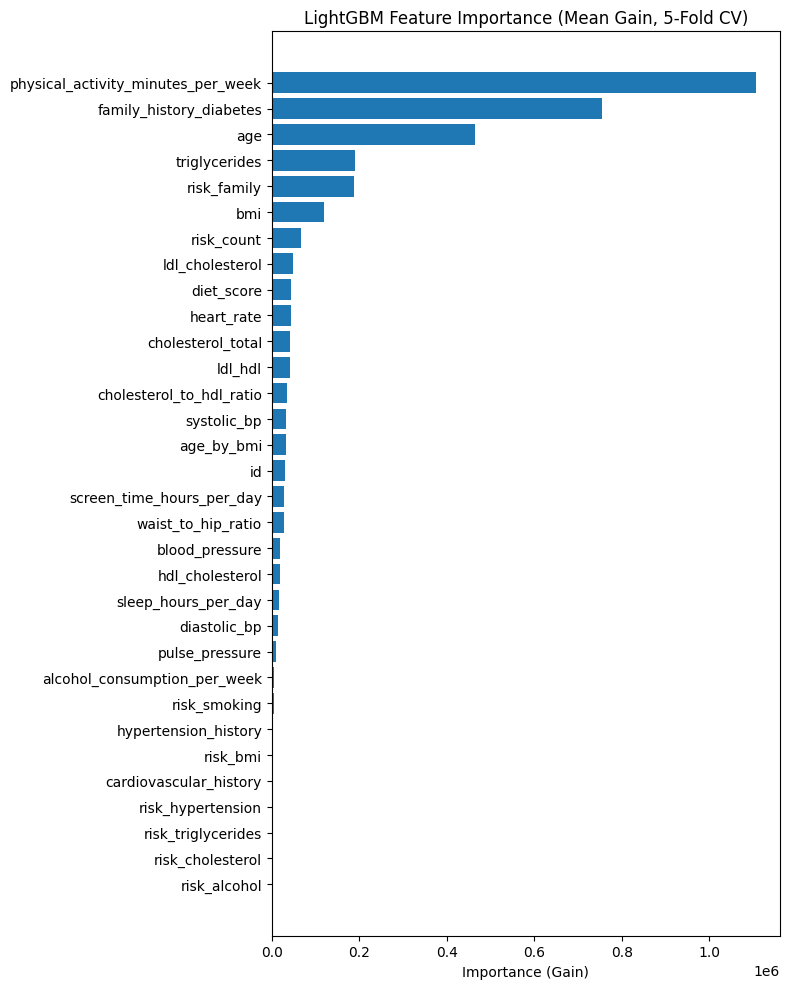

In [ ]:
target = "diagnosed_diabetes"

numeric_features = [
    'age', 'alcohol_consumption_per_week',
    'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day',
    'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
    'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
    'ldl_cholesterol', 'triglycerides', 'family_history_diabetes',
    'hypertension_history', 'cardiovascular_history'
]

categorical_features = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

# --- Feature engineering ---


def bmi_category(row):
    bmi = row['bmi']

    if bmi < 18.5:
        category = "underweight"
    elif bmi < 25:
        category = "normal"
    elif bmi < 30:
        category = "overweight"
    elif bmi < 35:
        category = "obesity_class_1"
    elif bmi < 40:
        category = "obesity_class_2"
    else:
        category = "obesity_class_3"

    return bmi, category


def bp_category(row):
    systolic = row["systolic_bp"]
    diastolic = row["diastolic_bp"]

    if systolic <= 0 or diastolic <= 0:
        return None

    if systolic >= 180 or diastolic >= 120:
        return "hypertensive_crisis"
    elif systolic >= 140 or diastolic >= 90:
        return "hypertension_stage_2"
    elif systolic >= 130 or diastolic >= 80:
        return "hypertension_stage_1"
    elif systolic >= 120 and diastolic < 80:
        return "elevated"
    else:
        return "normal"

# df["eth_bp_risk"] = df["ethnicity"].astype(str) + "_" + df.apply(lambda x: bp_cat(x["systolic_bp"], x["diastolic_bp"]), axis=1)


new_cols = []
def custom_preprocessor(main):
    data = main.copy()
    data["pulse_pressure"] = data.systolic_bp - data.diastolic_bp
    data["blood_pressure"] = data.systolic_bp / data.diastolic_bp
    data["age_by_bmi"] = data.age / data.bmi
    data['cholesterol_to_hdl_ratio'] = data.cholesterol_total / data.hdl_cholesterol
    data['ldl_hdl'] = data.ldl_cholesterol / data.hdl_cholesterol

    # data["tg_hdl"] = data["triglycerides"] / data["ldl_cholesterol"] 

        
    # data["bp_bmi_interaction"] = data["pulse_pressure"] * data["bmi"]
    # data["ldl_tg_interaction"] = data["ldl_cholesterol"] * data["triglycerides"]
    # data["bmi_age_interaction"] = data["bmi"] * data["age"]


    # data = data.drop('id', axis=1)   # ✅ fix: assign back

    # -------------------------------------------------------------------------------------- New
    
    data["bp_category"] = data.apply(bp_category, axis=1).astype('category')
    data["bmi_category"] = data.apply(bmi_category, axis=1).astype('category')
    
    data['risk_bmi'] = (data['bmi'] >= 30).astype(int)
    data['risk_cholesterol'] = (data['cholesterol_total'] >= 200).astype(int)
    data['risk_triglycerides'] = (data['triglycerides'] >= 150).astype(int)
    data['risk_hypertension'] = ((data['systolic_bp'] >= 130) | (data['diastolic_bp'] >= 80) | (data['hypertension_history'] == 1)).astype(int)
    data['risk_family'] = (data['family_history_diabetes'] == 1).astype(int)
    data['risk_smoking'] = (data['smoking_status'].str.lower().str.contains('current', na=False) | data['smoking_status'].str.lower().str.contains('former', na=False)).astype(int)

    # Re-run alcohol and diet risk for completeness
    alcohol_risk_men = (data['gender'].str.lower() == 'male') & (data['alcohol_consumption_per_week'] >= 14)
    alcohol_risk_women = (data['gender'].str.lower() == 'female') & (data['alcohol_consumption_per_week'] >= 7)
    data['risk_alcohol'] = (alcohol_risk_men | alcohol_risk_women).astype(int)
    # data['bmi_age_eth'] = data.bmi * ((False & (data.ethnicity.isin(['White', 'Other']))).astype(int) + 1) * data.age

    data['risk_count'] = (
        (data['hypertension_history'] == 1).astype(int)
        + (data['alcohol_consumption_per_week'] >= 1).astype(int)
        + 2*(data['family_history_diabetes'] == 1).astype(int)
        + (data['cardiovascular_history'] == 1).astype(int)
        + data['smoking_status'].isin(['Current','Former']).astype(int)
        + (data['bmi'] > 26.5).astype(int)
        + ((data['cholesterol_total'] > 240) & data['ldl_cholesterol'] > 150).astype(int)
        + data['waist_to_hip_ratio'] * 10 //100
        + (data['systolic_bp'] > 140).astype(int)
        + (data['diastolic_bp'] > 105).astype(int)    
        + (data['age'] > 48)
        + (data['diet_score'] < 2).astype(int)
    )
    epsilon=0.1
    data['daily_life_risk_index'] = (
        (data['sleep_hours_per_day']*60 / (data['physical_activity_minutes_per_week'] / 7 + epsilon))  # high sleep-to-activity ratio = more risk if activity is low
        * (1 - data['diet_score']/10)  # poor diet increases risk
        * (1 + data['alcohol_consumption_per_week'] / 7 + epsilon)  # alcohol amplifies risk
        * (1 + (data['bmi'] >= 26.5).astype(int))  # overweight doubles risk effect
        * (1 + (data['screen_time_hours_per_day'] >= 6).astype(int))  # high screen time amplifies risk
    )
    # -------------------------------------------------------------------------------------- New

    data[categorical_features]  = data[categorical_features].astype('category')
    new_cols.extend(list(set(data.columns) - set(main.columns) - set(new_cols)))
    print("New cols added:", new_cols)
    return data

# --- Apply preprocessing ---
df = train.copy()
X = custom_preprocessor(df.drop(columns=[target]))
y = df[target]

X_id = test['id'].copy()
X_sub = custom_preprocessor(test.copy())

# Add engineered features to numeric list
numeric_features = numeric_features + list(set(new_cols))

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def encoding_it(X_train, X_test, X_new=None):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    # Fit on training categorical data
    X_train_cat = encoder.fit_transform(X_train[categorical_features])
    X_test_cat  = encoder.transform(X_test[categorical_features])

    # If new data provided, transform it too
    if X_new is not None:
        X_new_cat = encoder.transform(X_new[categorical_features])
    else:
        X_new_cat = None

    # Convert to DataFrames with proper column names
    cat_cols = encoder.get_feature_names_out(categorical_features)
    X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols, index=X_train.index)
    X_test_cat  = pd.DataFrame(X_test_cat, columns=cat_cols, index=X_test.index)
    if X_new_cat is not None:
        X_new_cat = pd.DataFrame(X_new_cat, columns=cat_cols, index=X_new.index)

    # Keep numeric features
    X_train_num = X_train[numeric_features]
    X_test_num  = X_test[numeric_features]
    if X_new is not None:
        X_new_num = X_new[numeric_features]

    # Concatenate numeric + encoded categorical
    X_train_final = pd.concat([X_train_num.reset_index(drop=True),
                               X_train_cat.reset_index(drop=True)], axis=1)
    X_test_final  = pd.concat([X_test_num.reset_index(drop=True),
                               X_test_cat.reset_index(drop=True)], axis=1)

    if X_new is not None:
        X_new_final = pd.concat([X_new_num.reset_index(drop=True),
                                 X_new_cat.reset_index(drop=True)], axis=1)
        return X_train_final, X_test_final, X_new_final

    return X_train_final, X_test_final

# --- Apply encoding ---
# X_train, X_test, X_sub = encoding_it(X_train, X_test, X_new=X_sub)


lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.015,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 40,
    "subsample": 0.85,
    "colsample_bytree": 0.75,
    "lambda_l1": 8,
    "lambda_l2": 15,
    "n_estimators": 1500,
    # "class_weight": "balanced",
    "scale_pos_weight": 0.6,
    # "is_unbalanced": True,
    "verbose": -1,
    # "device_type": "gpu"
}


# ------------------------------

# Drop categorical features (since you're not encoding them)
X_model = X.drop(columns=categorical_features)
X_sub = X_sub.drop(columns=categorical_features)

feature_names = X_model.columns


# --- 5-Fold CV ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
test_preds = np.zeros((X_sub.shape[0], skf.n_splits))
feature_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_model, y), 1):
    X_train, X_val = X_model.iloc[train_idx], X_model.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMClassifier(**lgb_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        # verbose=False
    )

    y_val_pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred)
    auc_scores.append(auc)

    test_preds[:, fold - 1] = model.predict_proba(X_sub)[:, 1]
    # --- Feature importance (GAIN) ---
    feature_importances.append(
        model.booster_.feature_importance(importance_type="gain")
    )
    print(f"Fold {fold} AUC: {auc}")
    # print(f"Best Iteration: {model.booster_.best_iteration}")

# --- Final CV results ---
auc_scores = np.array(auc_scores)

print("\n📊 5-Fold CV Results")
print(f"AUCs: {auc_scores}")
print(f"Mean AUC: {auc_scores.mean():.7f}")
print(f"Std  AUC: {auc_scores.std():.7f}")
print(f"Mean AUC: {auc_scores.mean():.7f} ± {auc_scores.std():.5f}")

# ------------------------------

# lgb_model = lgb.LGBMClassifier(**lgb_params)

# lgb_model.fit(X_train.drop(columns=categorical_features), y_train)

# y_pred_val = lgb_model.predict_proba(X_test.drop(columns=categorical_features))[:, 1]
# lgb_auc = roc_auc_score(y_test, y_pred_val)

# print("LightGBM Validation AUC:", lgb_auc)  
# ------------------------------

mean_importance = np.mean(feature_importances, axis=0)

fi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": mean_importance
    })
    .sort_values("importance", ascending=False)
)

TOP_N = 60

plt.figure(figsize=(8, 10))
plt.barh(
    fi_df.head(TOP_N)["feature"][::-1],
    fi_df.head(TOP_N)["importance"][::-1]
)
plt.title("LightGBM Feature Importance (Mean Gain, 5-Fold CV)")
plt.xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()


|Notes                        |AUC                | LB         |
| --------------------------- | ----------------- | ---------- |
|Without categorical features |0.7260666838301622 |0.69657     |
|Without cat and l1:8, l2:12  |0.7267151330844877 |0.69630     |
|Adding  eth_bp_risk column   |0.7260818881152538 |          |
|Adding  employment_metabolic column |0.7258713759866644 |          |
|Adding  employment_metabolic column |0.7258713759866644 |          |
|5 fold with tg/hdl|0.7263247 ± 0.00077||
|Added features all with id|0.7264873 ± 0.00088| 0.70052|
|Addind self cooked risk|0.7265055 ± 0.00083|0.70072|
|regularized self cooked risk|0.7269859 ± 0.00077|0.70076|
|added bmi_age_eth and modified risk|0.7268659 ± 0.00077|0.70083|
|l1:8 l2:15|0.7272767 ± 0.00071|0.70085|
|risk_hypertension fixed limits|0.7273195 ± 0.00073|0.70082|
|misseed some params. full data|0.7273055 ± 0.00084|0.70077|

In [ ]:
# diagnosed_diabetes
# 1.0    4_36_307
# 0.0    2_63_693

eda = train.copy()
(
    (
        (eda['hypertension_history'] == 1)
        | (eda['alcohol_consumption_per_week'] >= 2)
        | (eda['family_history_diabetes'] == 1)
        | (eda['cardiovascular_history'] == 1)
        | (eda['smoking_status'].isin(['Current', 'Former']))
        | (eda['cholesterol_total'] > 190)
        | (eda['bmi'] > 25)
        | (eda['diet_score'] > 1)
        # | (eda['diet_score'] < 3)
    ) 
    # & 
    # (eda[target] == 1)
).value_counts()

True     699995
False         5
Name: count, dtype: int64

In [455]:
for i in numeric_features:
    print(i,X[i].corr(train[target]))

age 0.16116244935063534
alcohol_consumption_per_week 0.0029909312892261656
physical_activity_minutes_per_week -0.1697886841495706
diet_score -0.050119427210248854
sleep_hours_per_day 0.0035086035502993355
screen_time_hours_per_day 0.01821289827803201
bmi 0.10557996878711709
waist_to_hip_ratio 0.08104999548054517
systolic_bp 0.10713174027741097
diastolic_bp 0.0362707321606148
heart_rate 0.023864789245406744
cholesterol_total 0.08811223755173209
hdl_cholesterol -0.05323081593232119
ldl_cholesterol 0.10277129630996756
triglycerides 0.090635494017944
family_history_diabetes 0.21106415541400367
hypertension_history 0.02997947251418401
cardiovascular_history 0.024745597819409885
risk_hypertension 0.05528821730998949
bmi_age_eth 0.18464395142170242
risk_family 0.21106415541400367
daily_life_risk_index 0.11804830313635283
age_by_bmi 0.10096016841720111
risk_smoking 0.0012320104734819144
pulse_pressure 0.07664988405327779
cholesterol_to_hdl_ratio 0.09033591339822
risk_count 0.2231256972663958
r

In [16]:
X_train.age_smoke_bmi.value_counts()

age_smoke_bmi
mid_Never_overweight         96964
mid_Never_normal             67640
senior_Never_overweight      64966
young_Never_overweight       44678
senior_Never_normal          41935
young_Never_normal           34018
mid_Former_overweight        20357
mid_Current_overweight       20323
mid_Current_normal           14614
mid_Never_obese              13990
mid_Former_normal            13866
senior_Current_overweight    13571
senior_Former_overweight     13459
senior_Never_obese           10159
elder_Never_overweight        9331
young_Current_overweight      9175
young_Former_overweight       9106
senior_Current_normal         8789
senior_Former_normal          8481
young_Current_normal          7034
young_Former_normal           6798
young_Never_obese             5132
elder_Never_normal            4957
mid_Former_obese              2934
mid_Current_obese             2834
elder_Former_overweight       2081
senior_Former_obese           2074
elder_Current_overweight      1985
senior

In [465]:
# ------------------------------

lgb_model = lgb.LGBMClassifier(**lgb_params)

lgb_model.fit(X.drop(columns=categorical_features), y)

y_pred_val = lgb_model.predict_proba(X_sub)[:, 1]
# lgb_auc = roc_auc_score(y_test, y_pred_val)

# print("LightGBM Validation AUC:", lgb_auc)  
# ------------------------------
pd.DataFrame({"id": X_id, target: y_pred_val}).to_csv("lightgbmsub21.csv", index=False)

In [ ]:

# X_sub[categorical_features] = X_sub[categorical_features].astype('category')
final_test_pred = test_preds.mean(axis=1)
# probas = lgb_model.predict_proba(X_sub.drop(columns=categorical_features))[:,1]
pd.DataFrame({"id": X_id, target: final_test_pred}).to_csv("lightgbmsub20.csv", index=False)

In [224]:
# checks
df = train.copy()

df["htn_high_risk"] = (
    (df["systolic_bp"] >= 140) |
    (df["diastolic_bp"] >= 90)
).astype(int)


df["metabolic_high_risk"] = (
    (df["bmi"] >= 30) &
    (df["triglycerides"] >= 150) &
    (df["hdl_cholesterol"] < 40)
).astype(int)

df["obese_flag"] = ((df["bmi"] >= 30) & (df["metabolic_high_risk"] == 0) ).astype(int)


df["bp_bmi_high_risk"] = (
    ((df["systolic_bp"] >= 130) | (df["diastolic_bp"] >= 85)) &
    (df["bmi"] >= 30)
).astype(int)

df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]
df["htn_stage"] = pd.cut(df["systolic_bp"], bins=[0,120,130,140,200], labels=[0,1,2,3])
# df["htn_high_risk"] = ((df["systolic_bp"] >= 140) | (df["diastolic_bp"] >= 90)).astype(int)


df["lipid_high_risk"] = (
    (df["ldl_cholesterol"] >= 160) |
    (df["triglycerides"] >= 200)
).astype(int)


df["risk_burden"] = (
    (df["bmi"] >= 30).astype(int) +
    (df["systolic_bp"] >= 140).astype(int) +
    (df["triglycerides"] >= 150).astype(int) +
    (df["hdl_cholesterol"] < 40).astype(int)
)

df["ldl_high"] = (df["ldl_cholesterol"] >= 160).astype(int)
df["hdl_low"] = (df["hdl_cholesterol"] < 40).astype(int)
df["triglycerides_high"] = (df["triglycerides"] >= 150).astype(int)
df["ldl_hdl_ratio"] = df["ldl_cholesterol"] / df["hdl_cholesterol"]


df["tachycardia"] = (df["heart_rate"] >= 100).astype(int)
df["heart_rate_category"] = pd.cut(df["heart_rate"], bins=[40,60,80,100,200], labels=[0,1,2,3])

df["sedentary_flag"] = (df["physical_activity_minutes_per_week"] < 30).astype(int)
df["high_screen_time"] = (df["screen_time_hours_per_day"] > 6).astype(int)
df["alcohol_high"] = (df["alcohol_consumption_per_week"] > 6).astype(int)  # adjust threshold

df["metabolic_burden"] = (
    (df["bmi"] >= 30).astype(int) +
    (df["htn_high_risk"]).astype(int) +
    (df["triglycerides_high"]).astype(int) +
    (df["hdl_low"]).astype(int) +
    (df["ldl_high"]).astype(int)
)

df["bp_bmi_interaction"] = df["pulse_pressure"] * df["bmi"]
df["ldl_tg_interaction"] = df["ldl_cholesterol"] * df["triglycerides"]
df["bmi_age_interaction"] = df["bmi"] * df["age"]
df["metabolic_age_interaction"] = df["metabolic_burden"] * df["age"]
# df["metabolic_risk"] =  df["metabolic_burden"] + (df["risk_burden"]

# df["risk_burden_cat"] = pd.cut(
#     df["risk_burden"],
#     bins=[-1, 0, 1, 2, 4],
#     labels=["none", "low", "moderate", "high"]
# )

# print('risk_burden', roc_auc_score(y, df["risk_burden"]))
# print('risk_burden_cat', roc_auc_score(y, df["risk_burden_cat"]))

new_cols = list(set(df.columns) - set(train.columns))

for i in new_cols:
    # print(i)
    # print('ROC:', roc_auc_score(df[target], df[i]))
    print(i, df[i].corr(df[target]))
    # print('-'*20)

triglycerides_high 0.05243167821165185
lipid_high_risk 0.02229204085756133
hdl_low 0.027969129035898304
metabolic_age_interaction 0.09521732527472178
heart_rate_category 0.020204104754689766
htn_high_risk 0.0407368602686625
ldl_high 0.0176625936187083
ldl_tg_interaction 0.1268088628197898
tachycardia 0.0016094064895592715
sedentary_flag 0.06675441343524781
bp_bmi_interaction 0.10394116633067324
alcohol_high -0.0015593608927540908
pulse_pressure 0.07664988405327779
metabolic_burden 0.08227284475023094
ldl_hdl_ratio 0.09424690143431265
bmi_age_interaction 0.18464395142170242
htn_stage 0.08668805552524504
high_screen_time 0.017310376741247812
obese_flag 0.05739782664218327
metabolic_high_risk 0.017588856159750213
bp_bmi_high_risk 0.04448000193447804
risk_burden 0.08140676738717509


In [47]:
# findings
# bmi_age_interaction, ldl_tg_interaction, bp_bmi_interaction, ldl_hdl_ratio :: -- Strong
# pulse_pressure, htn_stage, metabolic_age_interaction, metabolic_burden :: -- Mild

In [15]:
X['hypertension_history'].value_counts()

hypertension_history
0    572607
1    127393
Name: count, dtype: int64

In [16]:
y.value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

In [27]:
eda.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64

In [76]:
# diagnosed_diabetes
# 1.0    4_36_307
# 0.0    2_63_693

eda = train.copy()
(
    (
        (eda['hypertension_history'] == 1)
        | (eda['alcohol_consumption_per_week'] >= 2)
        | (eda['family_history_diabetes'] == 1)
        | (eda['cardiovascular_history'] == 1)
        | (eda['smoking_status'].isin(['Current', 'Former']))
        | (eda['cholesterol_total'] > 190)
        | (eda['bmi'] > 25)
        | (eda['diet_score'] > 1)
        # | (eda['diet_score'] < 3)
    ) 
    # & 
    # (eda[target] == 1)
).value_counts()

True     699995
False         5
Name: count, dtype: int64

In [37]:
train.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

In [40]:
eda[eda[target]==1]['bmi'].describe()

count    436307.000000
mean         26.109489
std           2.852350
min          15.100000
25%          24.200000
50%          26.100000
75%          28.000000
max          38.400000
Name: bmi, dtype: float64

In [41]:
eda[eda[target]==0]['bmi'].describe()

count    263693.000000
mean         25.486175
std           2.832044
min          15.100000
25%          23.600000
50%          25.500000
75%          27.400000
max          38.400000
Name: bmi, dtype: float64

In [101]:
eda['risk_count'] = (eda['hypertension_history'])
+ (1 * (eda['alcohol_consumption_per_week']))
+ (1 * (eda['family_history_diabetes']))
+ (1 * (eda['cardiovascular_history']) )
+ (1 * (eda['smoking_status'].isin(['Current', 'Former']).astype(int)))
# + (1 * (eda['cholesterol_total']//100))
# + (2 * eda['bmi']/100)
        # | (eda['diet_score'] > )
        # | (eda['diet_score'] < 3)

print(eda['risk_count'].corr(eda[target]))
pd.crosstab(eda['risk_count'], eda[target], normalize='columns')


0.02997947251418401


diagnosed_diabetes,0.0,1.0
risk_count,,
0,0.832889,0.809018
1,0.167111,0.190982


In [200]:
eda['risk_count'] = (
    (eda['hypertension_history'] == 1).astype(int)
    + (eda['alcohol_consumption_per_week'] >= 2).astype(int)
    + 2*(eda['family_history_diabetes'] == 1).astype(int)
    + (eda['cardiovascular_history'] == 1).astype(int)
    + eda['smoking_status'].isin(['Current','Former']).astype(int)
    + (eda['bmi'] > 26.5).astype(int)
    + ((eda['cholesterol_total'] > 240) & eda['ldl_cholesterol'] > 150).astype(int)
    # + eda['ethnicity'].isin(['Hispanic']).astype(int)
    + eda['waist_to_hip_ratio'] * 10 //100
    + (eda['systolic_bp'] > eda['diastolic_bp']).astype(int)
    # + (eda['diet_score'] > 5).astype(int)
    # + (eda['diet_score'] > 4).astype(int)
    + (eda['age'] > 45)
    + (eda['diet_score'] < 2).astype(int)
)
print(eda['risk_count'].corr(eda[target]))
# print(((eda['cholesterol_total'] > 240) & eda['ldl_cholesterol'] > 160).astype(int).corr(eda[target]))
pd.crosstab(eda['risk_count'], eda[target], normalize='columns')

0.2074291464323666


diagnosed_diabetes,0.0,1.0
risk_count,,
0.0,0.000011,0.000002
1.0,0.058978,0.028920
2.0,0.233635,0.148842
3.0,0.341651,0.283747
4.0,0.244193,0.274493
5.0,0.094200,0.164224
6.0,0.022333,0.073370
7.0,0.004426,0.022830
8.0,0.000569,0.003424


In [203]:
# --- Assuming 'df' is your loaded DataFrame from previous steps ---

# --- 1. Define Individual Risk Columns (0 or 1) ---
# We reuse the boolean conditions from the previous run, but convert them to integers (0 or 1)

df['risk_bmi'] = (df['bmi'] >= 30).astype(int)
df['risk_cholesterol'] = (df['cholesterol_total'] >= 200).astype(int)
df['risk_triglycerides'] = (df['triglycerides'] >= 150).astype(int)
df['risk_hypertension'] = ((df['systolic_bp'] >= 130) | (df['diastolic_bp'] >= 80) | (df['hypertension_history'] == 1)).astype(int)
df['risk_family'] = (df['family_history_diabetes'] == 1).astype(int)
df['risk_smoking'] = (df['smoking_status'].str.lower().str.contains('current', na=False) | df['smoking_status'].str.lower().str.contains('former', na=False)).astype(int)

# Re-run alcohol and diet risk for completeness
alcohol_risk_men = (df['gender'].str.lower() == 'male') & (df['alcohol_consumption_per_week'] >= 14)
alcohol_risk_women = (df['gender'].str.lower() == 'female') & (df['alcohol_consumption_per_week'] >= 7)
df['risk_alcohol'] = (alcohol_risk_men | alcohol_risk_women).astype(int)

diet_threshold = df['diet_score'].quantile(0.25) # 5.00
df['risk_diet'] = (df['diet_score'] <= diet_threshold).astype(int)

# --- 2. Calculate the Total Risk Score (Sum of all 8 columns) ---
risk_columns = [
    'risk_bmi', 'risk_cholesterol', 'risk_triglycerides', 'risk_hypertension',
    'risk_family', 'risk_smoking', 'risk_alcohol', 'risk_diet'
]
df['total_risk_score'] = df[risk_columns].sum(axis=1)

# --- 3. Define the New High-Risk Profile (e.g., meeting 4 or more criteria) ---
RISK_THRESHOLD = 2
df['new_high_risk_profile'] = (df['total_risk_score'] >= RISK_THRESHOLD)

# --- 4. Analyze the New Profile ---
new_high_risk_count = df['new_high_risk_profile'].sum()
new_overall_risk_pct = (new_high_risk_count / total_count) * 100
new_high_risk_diabetic_count = df.loc[df['new_high_risk_profile'] == True, 'diagnosed_diabetes'].sum()
new_predictive_power_pct = (new_high_risk_diabetic_count / new_high_risk_count) * 100

print("\n--- New Risk Score Analysis (Threshold: 4 or more factors) ---")
print(f"Total individuals identified with NEW HIGH-RISK PROFILE: {new_high_risk_count:,}")
print(f"Overall Population Meeting New Profile: {new_overall_risk_pct:.2f}%")
print(f"Diabetic Prevalence within New Profile: {new_predictive_power_pct:.2f}%")


--- New Risk Score Analysis (Threshold: 4 or more factors) ---
Total individuals identified with NEW HIGH-RISK PROFILE: 351,107
Overall Population Meeting New Profile: 50.16%
Diabetic Prevalence within New Profile: 68.65%


In [185]:
eda.waist_to_hip_ratio

0         0.93
1         0.83
2         0.83
3         0.83
4         0.90
          ... 
699995    0.88
699996    0.85
699997    0.88
699998    0.86
699999    0.90
Name: waist_to_hip_ratio, Length: 700000, dtype: float64

In [137]:
df.screen_time_hours_per_day.describe()

count    700000.000000
mean          6.012733
std           2.022707
min           0.600000
25%           4.600000
50%           6.000000
75%           7.400000
max          16.500000
Name: screen_time_hours_per_day, dtype: float64

--- Diabetes Prevalence by gen_age ---
gen_age
Hispanic_8    84.861407
Black_8       83.208020
White_8       83.017591
Other_7       82.400932
Asian_8       82.027650
White_7       81.545942
Black_7       81.245075
Asian_7       80.495690
Hispanic_7    80.418410
Other_8       79.452055
Other_6       70.812604
Asian_6       70.480226
White_6       70.215542
Black_6       70.183584
Hispanic_6    69.852387
Other_1       66.666667
Other_5       65.689150
Asian_5       65.487907
Black_5       64.732451
White_5       64.679259
Hispanic_5    64.085842
Other_4       60.406699
Asian_4       59.446443
White_4       58.761118
Black_4       58.557163
Hispanic_4    57.859792
Other_3       56.293835
Asian_3       54.278596
White_3       53.881745
Black_3       53.794629
Hispanic_3    52.780463
Black_2       43.272520
White_2       42.804539
Other_2       41.885626
Hispanic_2    41.646109
Asian_2       41.479260
Black_1       41.463415
White_1       40.460526
Hispanic_1    39.423077
Asian_1       36.

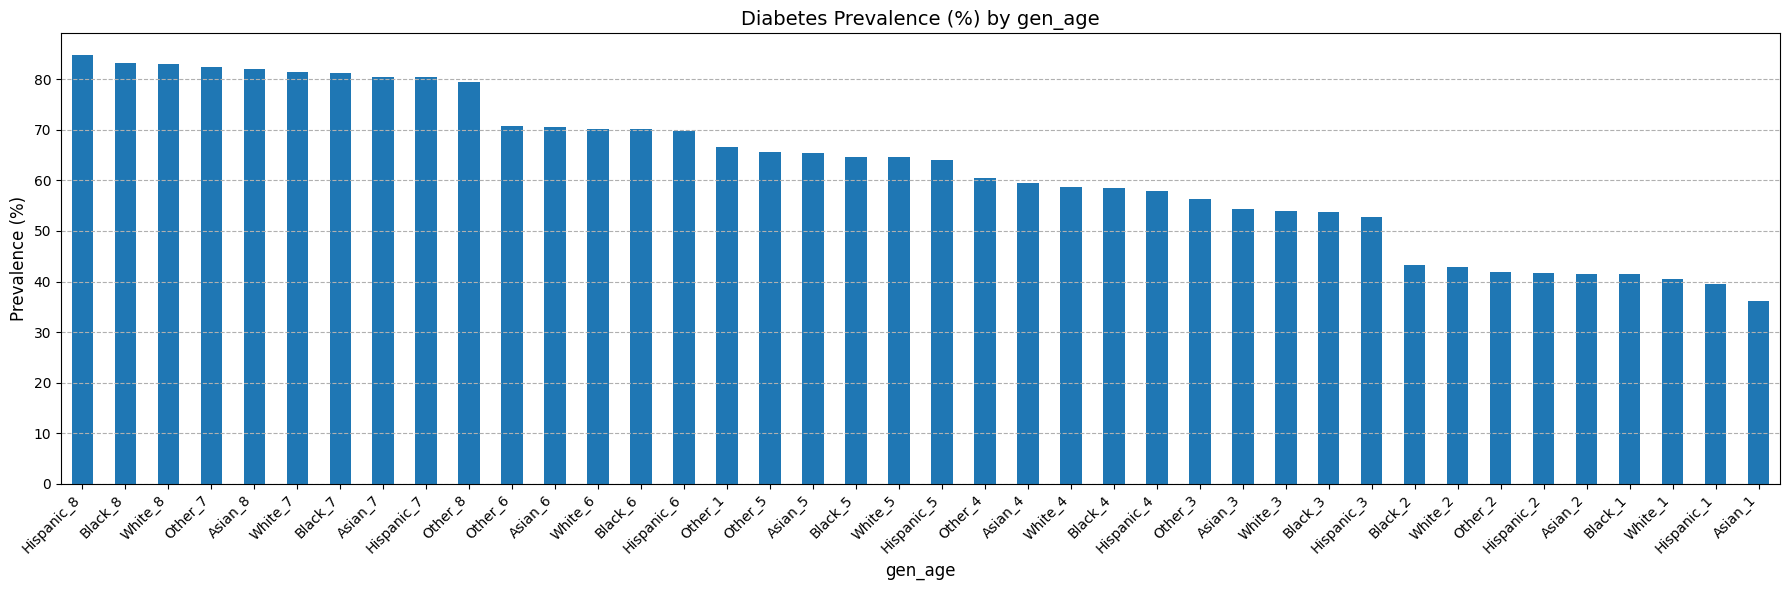

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Assuming the data is loaded into a DataFrame named 'df' ---
# df = pd.read_csv('your_data_file_name.csv')

# Define the categorical predictor and the binary target
df = train.copy()
# df['tri_sth_phy'] = (df.triglycerides//100).astype(str) + (df.screen_time_hours_per_day.astype(int)).astype(str) + (df.physical_activity_minutes_per_week//100).astype(str)
# categorical_column = 'tri_sth_phy'

# df['gen_age'] = df.gender + '_' + df.ethnicity + '_' + (df.age//10).astype(str)
df['gen_age'] =  df.ethnicity + '_' + (df.age//10).astype(str)
categorical_column = 'gen_age'
target_column = 'diagnosed_diabetes'

# 1. Calculate the prevalence (mean of the binary target) for each category
prevalence_by_category = df.groupby(categorical_column)[target_column].mean().sort_values(ascending=False)

# Convert the mean to a percentage for better readability
prevalence_by_category = prevalence_by_category * 100

# Print the results
print("--- Diabetes Prevalence by {} ---".format(categorical_column))
print(prevalence_by_category)

# 2. Visualize the results
plt.figure(figsize=(18, 6))
prevalence_by_category.plot(kind='bar')
plt.title(f'Diabetes Prevalence (%) by {categorical_column}', fontsize=14)
plt.xlabel(categorical_column, fontsize=12)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
# plt.savefig('diabetes_prevalence_by_ethnicity.png')
# plt.close()

In [152]:
# Libraries: Often requires custom function or specialized package (e.g., feature_engine)
df = train.copy()
df['gen_age'] =  df.ethnicity + '_' + (df.age//10).astype(str)
df['gen_eth_age'] = df.gender + '_' + df.ethnicity + '_' + (df.age//10).astype(str)
df['gen_eth'] = df.gender + '_' + df.ethnicity

def calculate_iv(df, feature, target):
    # 1. Group the data by the categorical feature
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    
    # 2. Calculate the proportion of non-events (0) and events (1)
    grouped['non_event_count'] = grouped['count'] - grouped['sum']
    
    # Calculate WOE (Weight of Evidence)
    grouped['woe'] = np.log((grouped['non_event_count'] / grouped['non_event_count'].sum()) / 
                            (grouped['sum'] / grouped['sum'].sum()))
    
    # Calculate IV
    grouped['IV'] = (grouped['sum'] / grouped['sum'].sum() - 
                     grouped['non_event_count'] / grouped['non_event_count'].sum()) * grouped['woe']
    
    # Return the sum of the IV column for the final score
    return grouped['IV'].sum()

# Example usage (assuming 'df' is your DataFrame):
iv_score = calculate_iv(df, 'gen_eth', target)
print(f"Information Value for gen_age: {iv_score}")

# Libraries often used: statsmodels or pingouin (for ANOVA)

# import statsmodels.api as sm
# from statsmodels.formula.api import ols

# # Formula: Target ~ Categorical_Column (e.g., diagnosed_diabetes ~ ethnicity)
# formula = 'diagnosed_diabetes ~ C(gen_eth_age)' # C() ensures it's treated as categorical

# # Perform ANOVA
# lm = ols(formula, data=df).fit()
# anova_table = sm.stats.anova_lm(lm, typ=2)

# The F-statistic tests significance, and the Sum Sq / Total Sum Sq gives a measure related to Eta Squared.
# Specialized libraries like 'pingouin' have direct eta_squared() functions.
# Example: pingouin.anova(data=df, dv='diagnosed_diabetes', between='ethnicity')['np2'] (for partial eta squared)

Information Value for gen_age: -0.00037822917556904384


In [ ]:
anova_table

,sum_sq,df,F,PR(>F)
C(gen_eth_age),4204.030432,114.0,161.156577,0.0
Residual,160154.686355,699885.0,NaN,NaN


In [142]:
display(prevalence_by_category.head(60))

tri_sth_phy
2928     100.0
2816     100.0
2925     100.0
290      100.0
292      100.0
281      100.0
2934     100.0
01142    100.0
01024    100.0
0038     100.0
0015     100.0
298      100.0
1564     100.0
0647     100.0
0551     100.0
0553     100.0
0650     100.0
0451     100.0
0453     100.0
0454     100.0
0457     100.0
0548     100.0
1363     100.0
1354     100.0
1357     100.0
2423     100.0
2634     100.0
2641     100.0
2622     100.0
2623     100.0
2624     100.0
11321    100.0
270      100.0
2632     100.0
21015    100.0
21016    100.0
21021    100.0
21022    100.0
2104     100.0
2105     100.0
11319    100.0
2116     100.0
2117     100.0
2118     100.0
11323    100.0
211      100.0
21110    100.0
11045    100.0
11135    100.0
1141     100.0
2715     100.0
2717     100.0
11220    100.0
11145    100.0
11141    100.0
11126    100.0
0141     100.0
01411    100.0
0248     100.0
2625     100.0
Name: diagnosed_diabetes, dtype: float64

In [94]:
pd.crosstab(eda['hypertension_history'], eda[target], normalize='columns')


diagnosed_diabetes,0.0,1.0
hypertension_history,,
0,0.832889,0.809018
1,0.167111,0.190982


In [63]:
eda['risk_score'] = (
    3 * (eda['family_history_diabetes'] == 1)
    + 2 * (eda['hypertension_history'] == 1)
    + 2 * (eda['cardiovascular_history'] == 1)
    + 1 * eda['smoking_status'].isin(['Current','Former'])
    + 1 * (eda['alcohol_consumption_per_week'] >= 2)
)
pd.crosstab(eda['risk_score'], eda[target], normalize='columns')


diagnosed_diabetes,0.0,1.0
risk_score,,
0,0.195580,0.153617
1,0.427364,0.344693
2,0.192030,0.163181
3,0.105649,0.133626
4,0.057563,0.125006
5,0.013095,0.044677
6,0.006640,0.025567
7,0.001892,0.008480
8,0.000148,0.000871


In [9]:
eda['my_risk_score'] = (
    3 * (eda['family_history_diabetes'] == 1)
    + 2 * (eda['hypertension_history'] == 1)
    + 2 * (eda['cardiovascular_history'] == 1)
    + 1 * eda['smoking_status'].isin(['Current','Former'])
    + 1 * (eda['alcohol_consumption_per_week'] >= 2)
)
(
    (
        eda['my_risk_score'] > 1        
    ) 
    & 
    (eda[target] == 1)
).value_counts()

False    481109
True     218891
Name: count, dtype: int64

In [ ]:
# 1_57_874
# (eda['hypertension_history'] == 1) | (eda['alcohol_consumption_per_week'] >= 6) | (eda['family_history_diabetes'] == 1) 

# 1_67_702
# (eda['hypertension_history'] == 1) | (eda['alcohol_consumption_per_week'] >= 6) | (eda['family_history_diabetes'] == 1) | (eda['cardiovascular_history'] == 1)

# 2_47_020
# (eda['hypertension_history'] == 1) | (eda['alcohol_consumption_per_week'] >= 6) | (eda['family_history_diabetes'] == 1) | (eda['cardiovascular_history'] == 1) | (eda['smoking_status'].isin(['Current', 'Former']))

# 3_69_283
# (eda['hypertension_history'] == 1) | (eda['alcohol_consumption_per_week'] >= 2) | (eda['family_history_diabetes'] == 1) | (eda['cardiovascular_history'] == 1) | (eda['smoking_status'].isin(['Current', 'Former']))


In [29]:
eda.alcohol_consumption_per_week.value_counts()

alcohol_consumption_per_week
2    246592
1    246311
3    137565
4     52973
5     13322
6      2728
7       447
8        59
9         3
Name: count, dtype: int64

In [83]:
train.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [87]:
for i in categorical_features:
    print(train[i].value_counts())

gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64
ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64
education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64
income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64
smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64
employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64


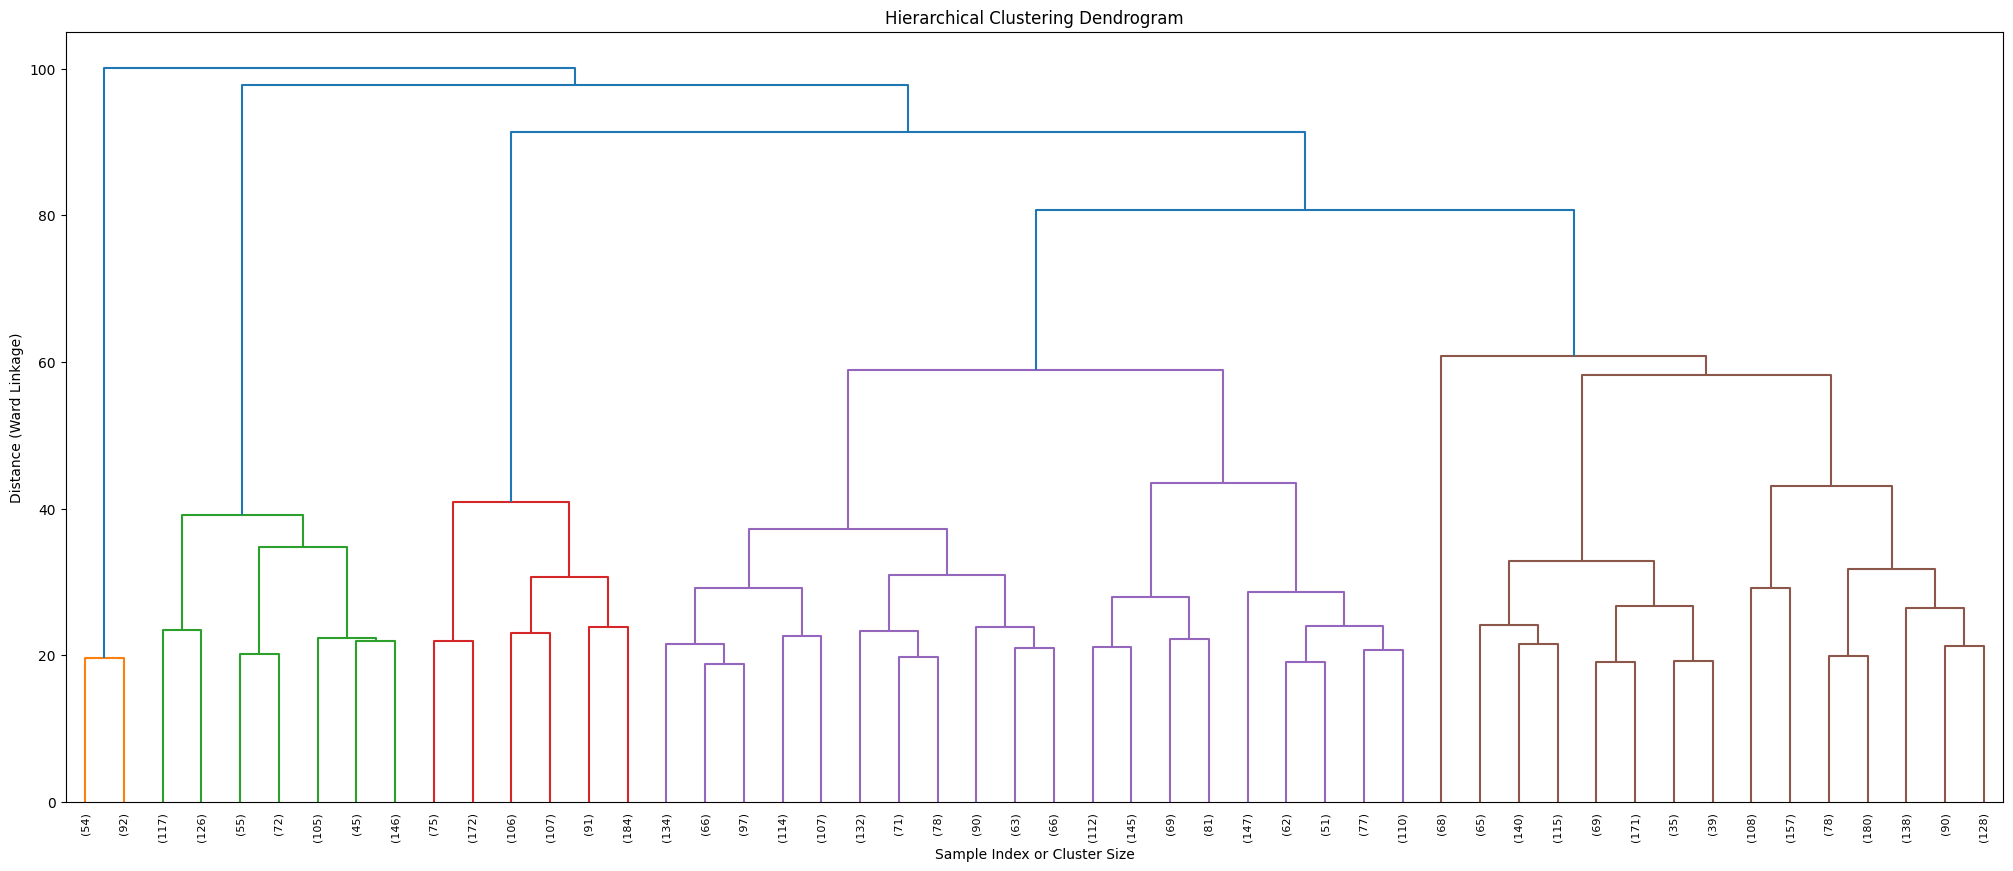

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. Load Data and Select a Sample (Essential for 700k rows!)
# Assuming your data is in a DataFrame called 'df'
# df_sample = df.sample(n=5000, random_state=42)
# features = ['age', 'bmi', 'systolic_bp', 'hdl_cholesterol', ...]
# X = df_sample[features]
df = train.copy()
X_sample = df.sample(n=5000, random_state=42) # Assuming 'df' is your full DataFrame
# 2. Scale the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample[[x for x in numeric_features if x in train.columns]])

# 3. Compute the Linkage Matrix (The Clustering Step)
# 'ward' linkage minimizes the variance within each cluster
Z = linkage(X_scaled, method='ward')

# 4. Generate and Plot the Dendrogram
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance (Ward Linkage)')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last 'p' merged clusters
    p=50,                   # show only the last 50 merges/clusters
    show_leaf_counts=True,
)
plt.show()

In [227]:
# BMI ≥ 30
# Total cholesterol ≥ 200
# Triglycerides ≥ 150
# Hypertension (≥130/80 or diagnosis)
# Family history = yes
# Smoking = current or former
# Alcohol ≥ 14/week (men), ≥7/week (women)
# Diet score ≤ bottom quartile

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt

corrcols = [x for x in numeric_features if x in train.columns]
df = train.copy()
init_cols = set(df.columns)
df['pulse_pressure'] = df.systolic_bp - df.diastolic_bp
df['bmi_wth_age'] = (df.bmi * df.waist_to_hip_ratio * df.age) 
df['triglycerides_np'] = np.log10(df.triglycerides) 
new_cols = list(set(df.columns) - init_cols)
corrcols += new_cols


# Compute Spearman correlations with target
corr_target = (
    df[corrcols + [target]]
       .corr(method='spearman')['diagnosed_diabetes']
       .drop('diagnosed_diabetes')
       .reset_index()
)

corr_target.columns = ['feature', 'correlation']
# Sort for better visualization
corr_target = corr_target.sort_values('correlation')
print(corr_target)

# # Plot
# plt.figure(figsize=(8, 6))
# sns.barplot(
#     data=corr_target,
#     x='correlation',
#     y='feature',
#     palette='coolwarm'
# )

# plt.axvline(0, color='black', linewidth=1)
# plt.xlabel('Spearman Correlation with Diagnosed Diabetes')
# plt.ylabel('')
# plt.title('Feature Correlation with Diabetes')
# plt.tight_layout()
# plt.show()


                               feature  correlation
2   physical_activity_minutes_per_week    -0.162939
12                     hdl_cholesterol    -0.052727
3                           diet_score    -0.049691
4                  sleep_hours_per_day     0.003849
1         alcohol_consumption_per_week     0.004753
5            screen_time_hours_per_day     0.018234
10                          heart_rate     0.022616
17              cardiovascular_history     0.024746
16                hypertension_history     0.029979
9                         diastolic_bp     0.034920
20                      pulse_pressure     0.074616
7                   waist_to_hip_ratio     0.079840
11                   cholesterol_total     0.083683
18                    triglycerides_np     0.089697
14                       triglycerides     0.089697
13                     ldl_cholesterol     0.099072
6                                  bmi     0.103140
8                          systolic_bp     0.103735
0           

In [ ]:
eda = train.copy()
eda['pulse_pressure'] = eda.systolic_bp - eda.diastolic_bp
eda['new'] = eda.pulse_pressure
eda['new'] = eda.bmi * ((False & (eda.ethnicity.isin(['White', 'Other']))).astype(int) + 1) * eda.cholesterol_total
# eda['new'] = ((eda.ethnicity == 'Hispanic').astype(int) + 1) * eda.

# eda['bmi_risk'] = 0

# # Asian / South Asian: lower BMI cutoff
# eda.loc[
#     (eda['ethnicity'] == 'Asian') & (eda['bmi'] >= 23),
#     'bmi_risk'
# ] = 1


# # Everyone else
# eda.loc[
#     (~eda['ethnicity'].isin(['Asian'])) & (eda['bmi'] >= 25),
#     'bmi_risk'
# ] = 1


# eda['dyslipidemia_risk'] = (
#     (eda['triglycerides'] >= 150) &
#     (
#         ((eda['ethnicity'] == 'White') & (eda['hdl_cholesterol'] < 40)) |
#         ((eda['ethnicity'] != 'White') & (eda['hdl_cholesterol'] < 45))
#     )
# ).astype(int)

# eda['early_age_risk'] = 0

# eda.loc[
#     (eda['ethnicity'] != 'White') & (eda['age'] < 45),
#     'early_age_risk'
# ] = 1

# eda.loc[
#     (eda['ethnicity'] == 'White') & (eda['age'] < 50),
#     'early_age_risk'
# ] = 1


# eda['bp_risk'] = (
#     (eda['systolic_bp'] >= 130) |
#     (eda['diastolic_bp'] >= 80)
# ).astype(int)


# eda['thin_fat_risk'] = (
#     (eda['bmi'] < 25) &
#     (eda['ethnicity'].isin(['Asian'])) &
#     (
#         (eda['triglycerides'] >= 150) |
#         (eda['hdl_cholesterol'] < 45)
#     )
# ).astype(int)


# eda['ethnic_risk_score'] = (
#     2 * eda['bmi_risk']
#     + 2 * eda['dyslipidemia_risk']
#     + 1 * eda['bp_risk']
#     + 1 * eda['early_age_risk']
#     + 1 * eda['thin_fat_risk']
# )

# print(pd.crosstab(
#     eda['ethnic_risk_score'],
#     eda['diagnosed_diabetes'],
#     normalize='columns'
# )
# )

eda['new'] = eda.

pd.crosstab(eda['ethnic_risk_score'], eda[target])
# eda.ethnicity.value_counts()
print(eda.ethnic_risk_score.corr(eda[target]))

diagnosed_diabetes       0.0       1.0
ethnic_risk_score                     
0                   0.133940  0.129079
1                   0.231777  0.172285
2                   0.211686  0.245683
3                   0.339057  0.370927
4                   0.075899  0.070013
5                   0.006318  0.010199
6                   0.001305  0.001797
7                   0.000019  0.000018
0.04120763864885061


In [ ]:
# New interactions
eda['bmi_age_eth'] = eda.bmi * ((False & (eda.ethnicity.isin(['White', 'Other']))).astype(int) + 1) * eda.age


In [306]:
df.ethnicity.value_counts()

ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64

In [ ]:
data = train.copy()
data['risk_count'] = (
    (data['hypertension_history'] == 1).astype(int)
    + (data['alcohol_consumption_per_week'] >= 1).astype(int)
    + 2*(data['family_history_diabetes'] == 1).astype(int)
    + (data['cardiovascular_history'] == 1).astype(int)
    + data['smoking_status'].isin(['Current','Former']).astype(int)
    + (data['bmi'] > 26.5).astype(int)
    + ((data['cholesterol_total'] > 240) & data['ldl_cholesterol'] > 150).astype(int)
    + data['waist_to_hip_ratio'] * 10 //100
    + (data['systolic_bp'] > 140).astype(int)
    + (data['diastolic_bp'] > 105).astype(int)    
    + (data['age'] > 48)
    + (data['diet_score'] < 2).astype(int)
)

# eda.ethnicity.value_counts()
print(data['risk_count'].corr(X[target]))
print(pd.crosstab(data['risk_count'], data[target]))

0.899295535716423
diagnosed_diabetes    0.0     1.0
risk_count                       
1.0                 52538   46621
2.0                 96456  120516
3.0                 74579  129714
4.0                 30600   83846
5.0                  7749   39728
6.0                  1537   13350
7.0                   230    2342
8.0                     4     181
9.0                     0       9


In [390]:
# 
eda = train.copy()
eda['high_screen'] = (eda['screen_time_hours_per_day'] >= 6).astype(int)

eda['low_activity'] = (eda['physical_activity_minutes_per_week'] < 150).astype(int)

eda['high_alcohol'] = (eda['alcohol_consumption_per_week'] >= 14).astype(int)

eda['short_sleep'] = (eda['sleep_hours_per_day'] < 6).astype(int)

eda['overweight'] = (eda['bmi'] >= 25).astype(int)

eda['insulin_resistance'] = (
    (eda['triglycerides'] >= 150) |
    (eda['hdl_cholesterol'] < 40)
).astype(int)

eda['sedentary_obesity'] = (
    eda['high_screen'] & eda['overweight']
).astype(int)

eda['inactive_dyslipidemia'] = (
    eda['low_activity'] & eda['insulin_resistance']
).astype(int)
eda['alcohol_metabolic_stress'] = (
    eda['high_alcohol'] & eda['overweight']
).astype(int)
eda['sleep_ir'] = (
    eda['short_sleep'] & eda['insulin_resistance']
).astype(int)

eda['lifestyle_cluster'] = (
    eda['high_screen']
    + eda['low_activity']
    + eda['high_alcohol']
    + eda['short_sleep']
)
eda['lifestyle_metabolic_score'] = (
    2 * eda['sedentary_obesity']
    + 2 * eda['inactive_dyslipidemia']
    + 1 * eda['alcohol_metabolic_stress']
    + 2 * eda['sleep_ir']
    + 1 * (eda['lifestyle_cluster'] >= 3)
)
print("corr", eda['lifestyle_metabolic_score'].corr(eda[target]))
pd.crosstab(
    eda['lifestyle_metabolic_score'],
    eda['diagnosed_diabetes'],
    normalize='columns'
)


corr 0.07781633113677826


diagnosed_diabetes,0.0,1.0
lifestyle_metabolic_score,,
0,0.619550,0.546381
1,0.020160,0.018058
2,0.273265,0.314237
3,0.024817,0.029060
4,0.054783,0.081026
5,0.001305,0.001410
7,0.006121,0.009828


In [ ]:
eda['new'] = (eda['sleep_hours_per_day']*60) / ((eda['physical_activity_minutes_per_week']/7 )) * (1 - eda['diet_score']/10)  # / eda['alcohol_consumption_per_week']/7) / 
# eda['new'] = (eda['sleep_hours_per_day']*60) * (1 - eda['diet_score']/10) * (eda['alcohol_consumption_per_week']/7)  # / eda['alcohol_consumption_per_week']/7) / 

print("corr", (eda['new']).corr(eda[target]))


corr -0.11293214427772857


In [ ]:
# small epsilon to avoid division by zero
epsilon = 0.1

# Daily physical activity
eda['daily_activity'] = eda['physical_activity_minutes_per_week'] / 7 + epsilon

# Normalize diet score (assuming 0-10 scale)
eda['diet_adj'] = 1 - eda['diet_score']/10

# Screen time flag (hours per day)
eda['high_screen'] = (eda['screen_time_hours_per_day'] >= 6).astype(int)

# Alcohol (standard drinks per week)
eda['daily_alcohol'] = eda['alcohol_consumption_per_week'] / 7 + epsilon

# Overweight flag
eda['overweight'] = (eda['bmi'] >= 26.5).astype(int)

eda['daily_life_risk_index'] = (
    (eda['sleep_hours_per_day']*60 / (eda['physical_activity_minutes_per_week'] / 7 + epsilon))  # high sleep-to-activity ratio = more risk if activity is low
    * (1 - eda['diet_score']/10)  # poor diet increases risk
    * (1 + eda['alcohol_consumption_per_week'] / 7 + epsilon)  # alcohol amplifies risk
    * (1 + (eda['bmi'] >= 26.5).astype(int))  # overweight doubles risk effect
    * (1 + (eda['screen_time_hours_per_day'] >= 6).astype(int))  # high screen time amplifies risk
)
print(eda['daily_life_risk_index'].corr(eda[target]))

pd.crosstab(
    pd.qcut(eda['daily_life_risk_index'], q=7),  # deciles
    eda['diagnosed_diabetes'],
    normalize='columns'
)


0.11906213601905875


diagnosed_diabetes,0.0,1.0
daily_life_risk_index,,
"(0.0613, 11.832]",0.194764,0.111486
"(11.832, 18.895]",0.166527,0.128554
"(18.895, 26.892]",0.152188,0.137218
"(26.892, 37.027]",0.139810,0.144699
"(37.027, 52.047]",0.129006,0.151226
"(52.047, 80.081]",0.117716,0.158052
"(80.081, 4032.864]",0.099987,0.168766
